## Exploratory Data Analysis (EDA)

Let's explore the dataset to understand feature distributions, relationships, and target balance.

# Predictive Maintenance: Binary Classification of Machine Failures

This notebook demonstrates how to build a binary classification model to predict machine failures using the `predictive_maintenance.csv` dataset. We will walk through data loading, preprocessing, feature engineering, model training, evaluation, and prediction steps.

## 1. Load and Explore Data

Load the dataset and perform initial exploration to understand its structure and check for missing values.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data/predictive_maintenance.csv')

# Display the first few rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
# Basic statistics and missing values
print('Shape:', df.shape)
df.info()
df.describe()
print('\nMissing values per column:')
print(df.isnull().sum())

Shape: (10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperatu

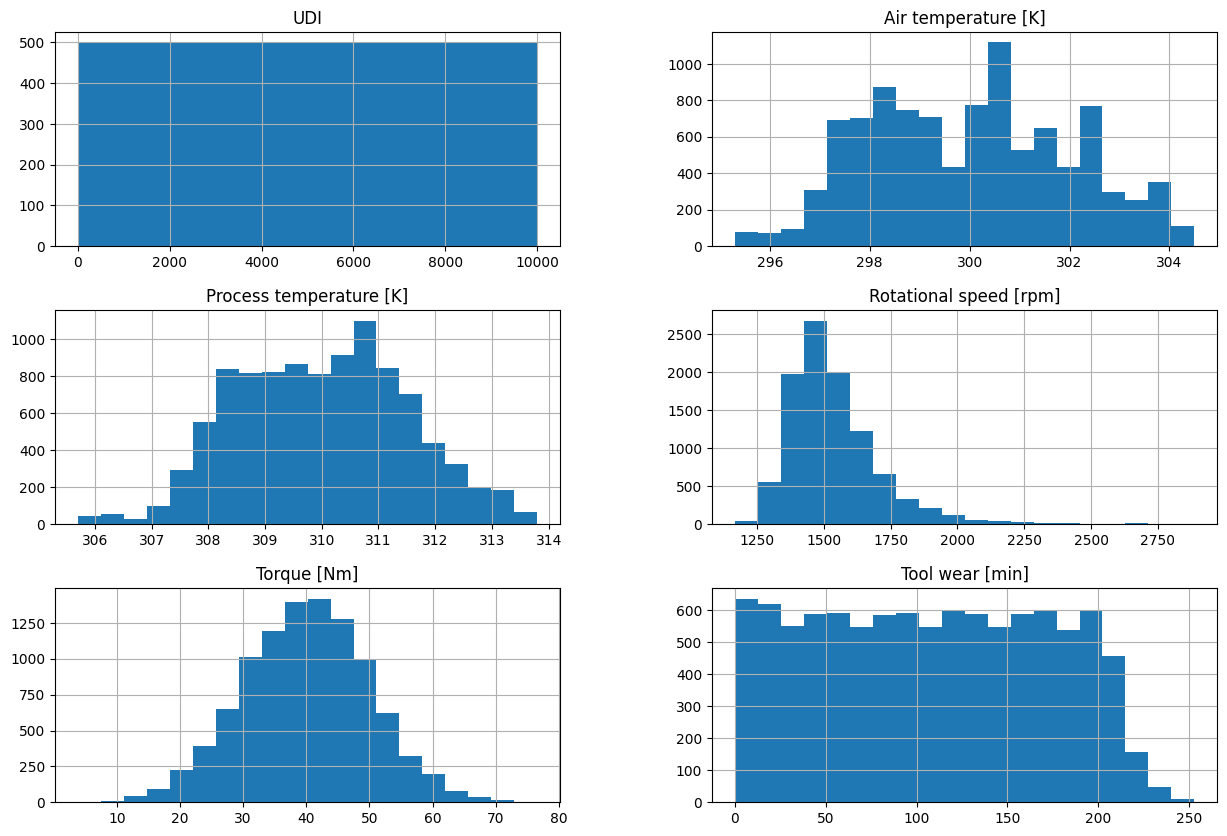

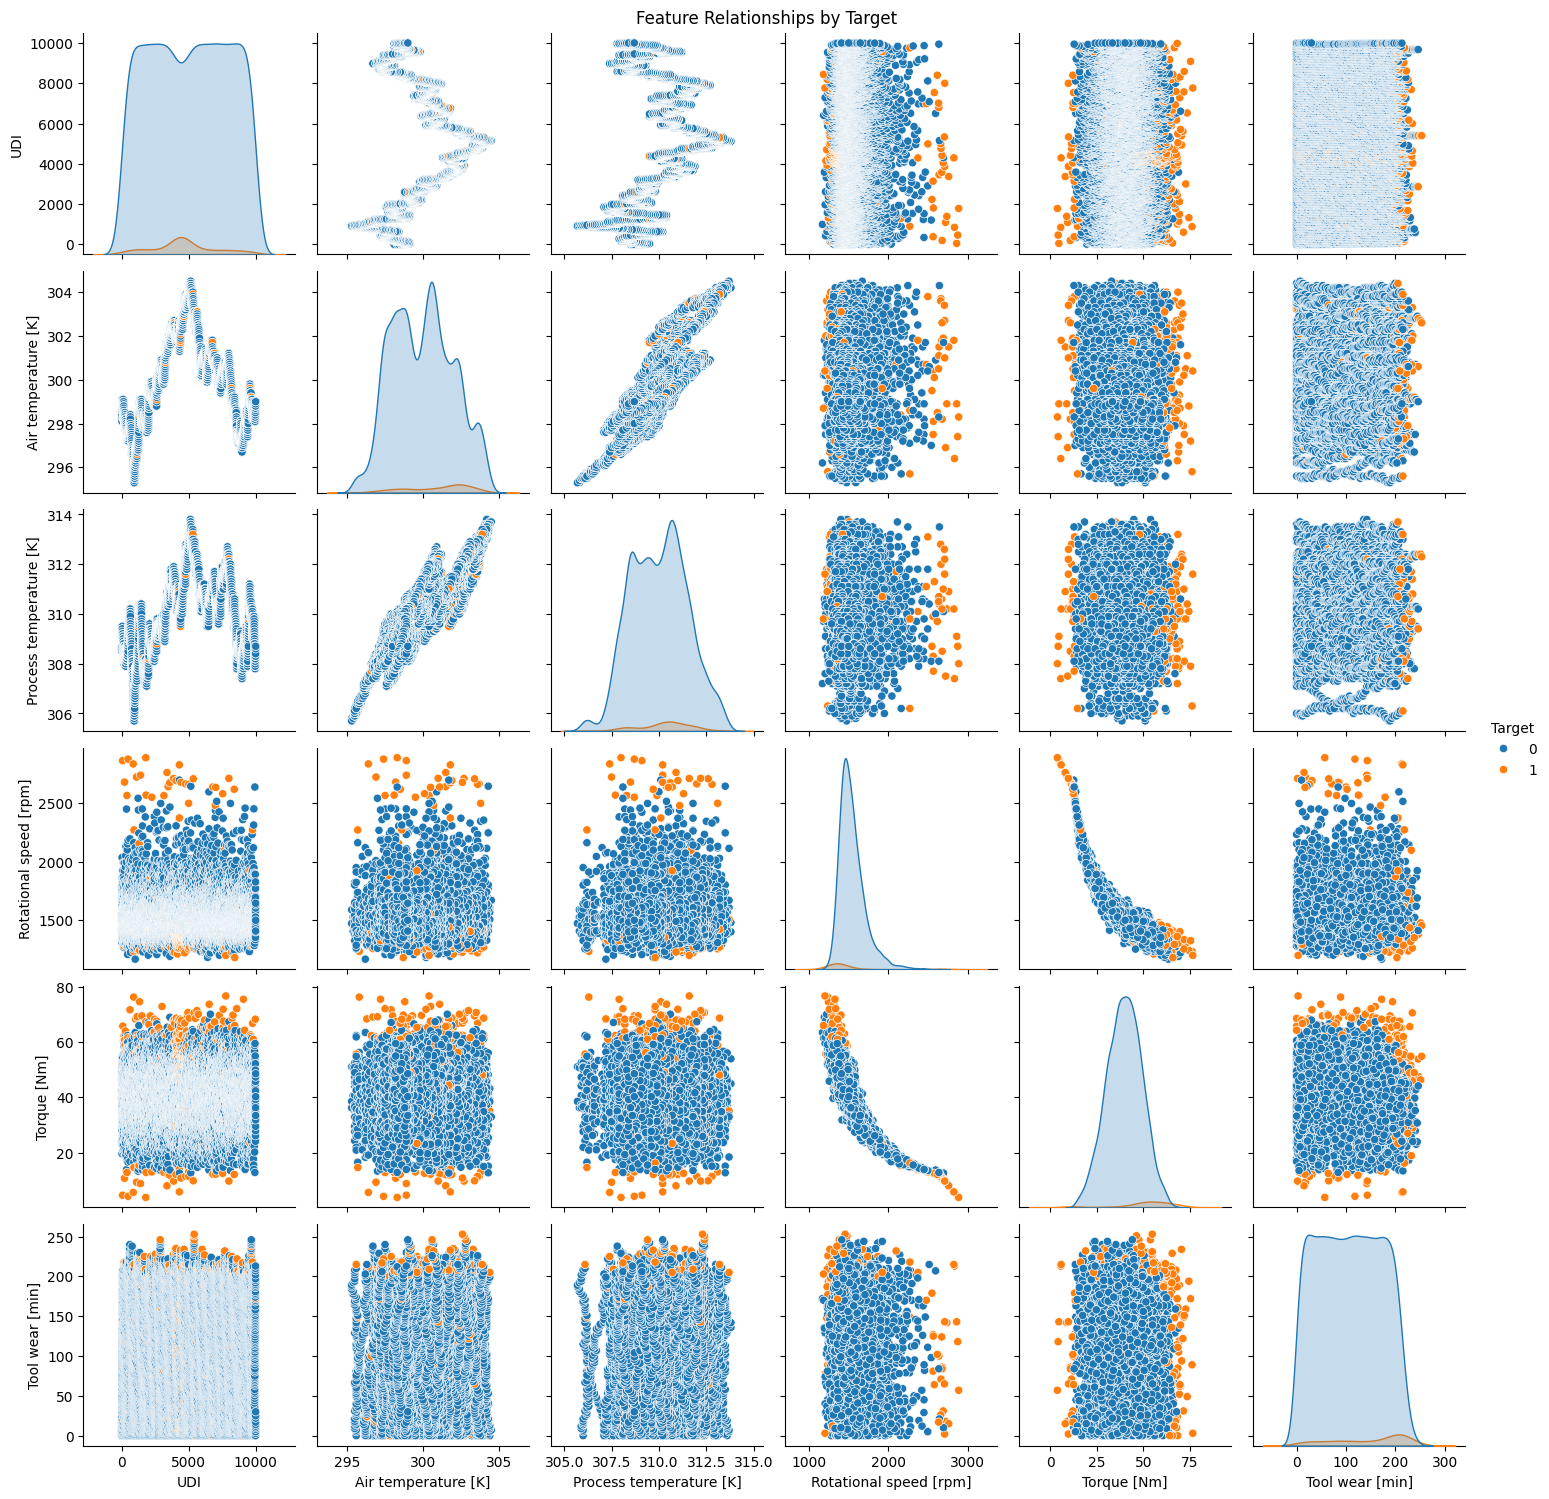


Class Balance:
Target
0    9661
1     339
Name: count, dtype: int64

Class Distribution (%):
Target
0    96.61
1     3.39
Name: proportion, dtype: float64


In [4]:
# Distribution of numerical features
num_features = [col for col in df.columns if df[col].dtype in [np.float64, np.int64] and col != 'Target']
df[num_features].hist(figsize=(15, 10), bins=20)

# Pairplot to see relationships between features
sns.pairplot(df[num_features + ['Target']], hue='Target', diag_kind='kde')
plt.suptitle('Feature Relationships by Target', y=1.001)
plt.show()


print('\nClass Balance:')
print(df['Target'].value_counts())
print(f'\nClass Distribution (%):')
print(df['Target'].value_counts(normalize=True) * 100)

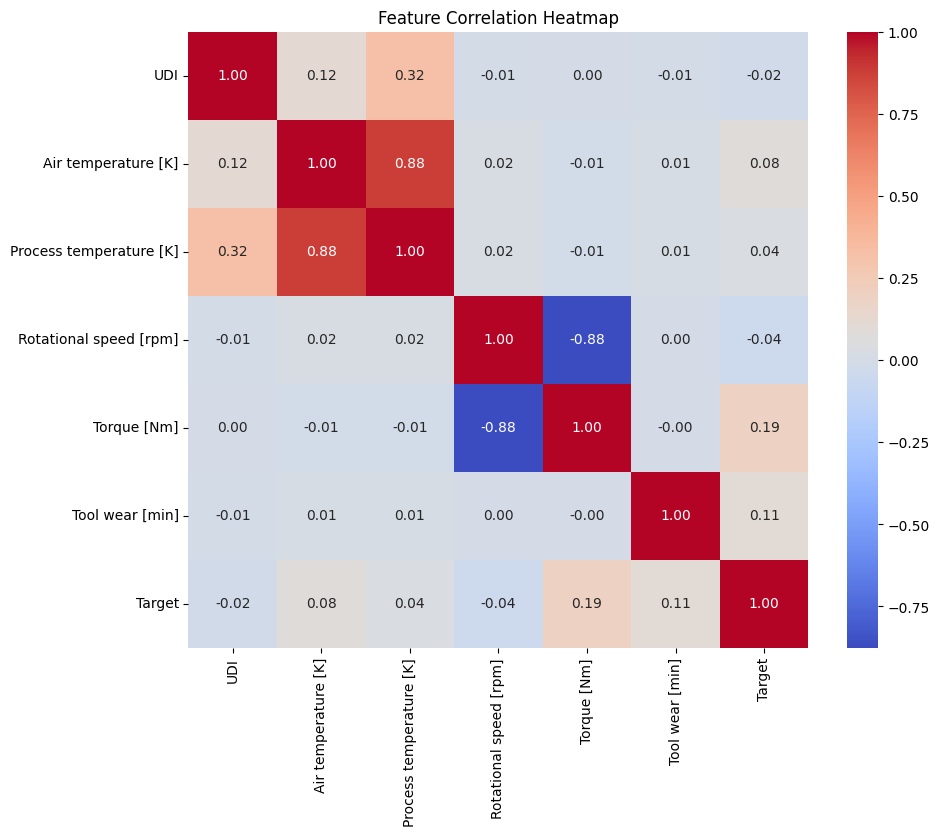

In [5]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

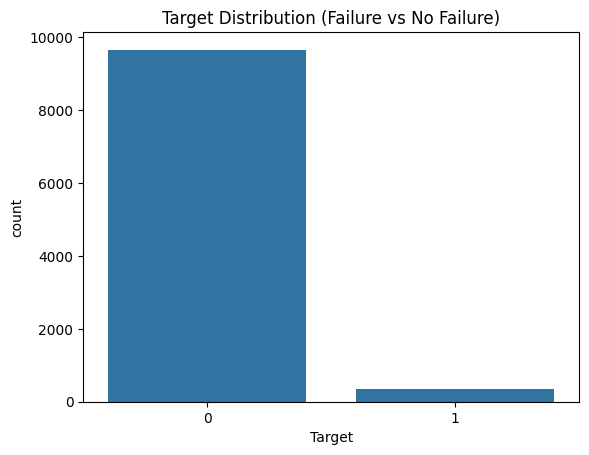

In [6]:
# Target variable distribution
sns.countplot(x='Target', data=df)
plt.title('Target Distribution (Failure vs No Failure)')
plt.show()

## 2. Preprocess Data for Binary Classification

Convert the target column to binary labels and handle categorical features as needed.

In [7]:
# Convert target column to binary labels
# Assuming 'Failure Type' column exists, create a binary target: 1 if any failure, 0 otherwise
if 'Failure Type' in df.columns:
    df['Target'] = df['Failure Type'].apply(lambda x: 0 if x == 'No Failure' else 1)
else:
    # If already binary, just rename for clarity
    df['Target'] = df['Target']

# Drop columns not needed for modeling (e.g., 'Failure Type', 'UDI', 'Product ID')
drop_cols = [col for col in ['Failure Type', 'UDI', 'Product ID'] if col in df.columns]
df = df.drop(columns=drop_cols)

df['Target'].value_counts()

Target
0    9652
1     348
Name: count, dtype: int64

## 3. Feature Engineering

Select relevant features, encode categorical variables, and scale numerical features if needed.

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables (e.g., 'Type')
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col != 'Target']
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Scale numerical features
num_cols = [col for col in df.columns if col not in categorical_cols + ['Target']]
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,2,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0
1,1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0
2,1,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0
3,1,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0
4,1,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0


## 4. Split Data into Train and Test Sets

Divide the data into training and testing sets for model evaluation.

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (8000, 6)
Test shape: (2000, 6)


## 5. Train a Binary Classification Model

Train a classification model (Random Forest) using the training data.

In [10]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store all model results
results = {}


# 1. Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
}


Training Logistic Regression...


In [11]:
# 2. Random Forest
from sklearn.model_selection import GridSearchCV

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
}


Training Random Forest...


In [12]:
# 3. Gradient Boosting
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_test, y_pred_gb),
    'precision': precision_score(y_test, y_pred_gb),
    'recall': recall_score(y_test, y_pred_gb),
    'f1': f1_score(y_test, y_pred_gb),
    'roc_auc': roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
}


Training Gradient Boosting...


In [13]:
# 4. Support Vector Machine
print("Training SVM...")
svm = SVC(kernel='rbf', random_state=42, probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
results['SVM (RBF)'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'precision': precision_score(y_test, y_pred_svm),
    'recall': recall_score(y_test, y_pred_svm),
    'f1': f1_score(y_test, y_pred_svm),
    'roc_auc': roc_auc_score(y_test, svm.predict_proba(X_test)[:, 1])
}


Training SVM...


In [14]:
# 5. K-Nearest Neighbors
print("Training KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
results['KNN (k=5)'] = {
    'accuracy': accuracy_score(y_test, y_pred_knn),
    'precision': precision_score(y_test, y_pred_knn),
    'recall': recall_score(y_test, y_pred_knn),
    'f1': f1_score(y_test, y_pred_knn),
    'roc_auc': roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1])
}


Training KNN...


## 6. Evaluate Model Performance

Assess the model using accuracy, precision, recall, F1-score, and confusion matrix.

In [15]:
# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).T
print("\n" + "="*80)
print("MODEL COMPARISON REPORT")
print("="*80)
print(results_df.round(4))
print("\n" + "="*80)



MODEL COMPARISON REPORT
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.9670     0.7000  0.1000  0.1750   0.9231
Random Forest          0.9860     0.9200  0.6571  0.7667   0.9812
Gradient Boosting      0.9835     0.9302  0.5714  0.7080   0.9849
SVM (RBF)              0.9695     0.9091  0.1429  0.2469   0.9439
KNN (k=5)              0.9735     0.8400  0.3000  0.4421   0.8627



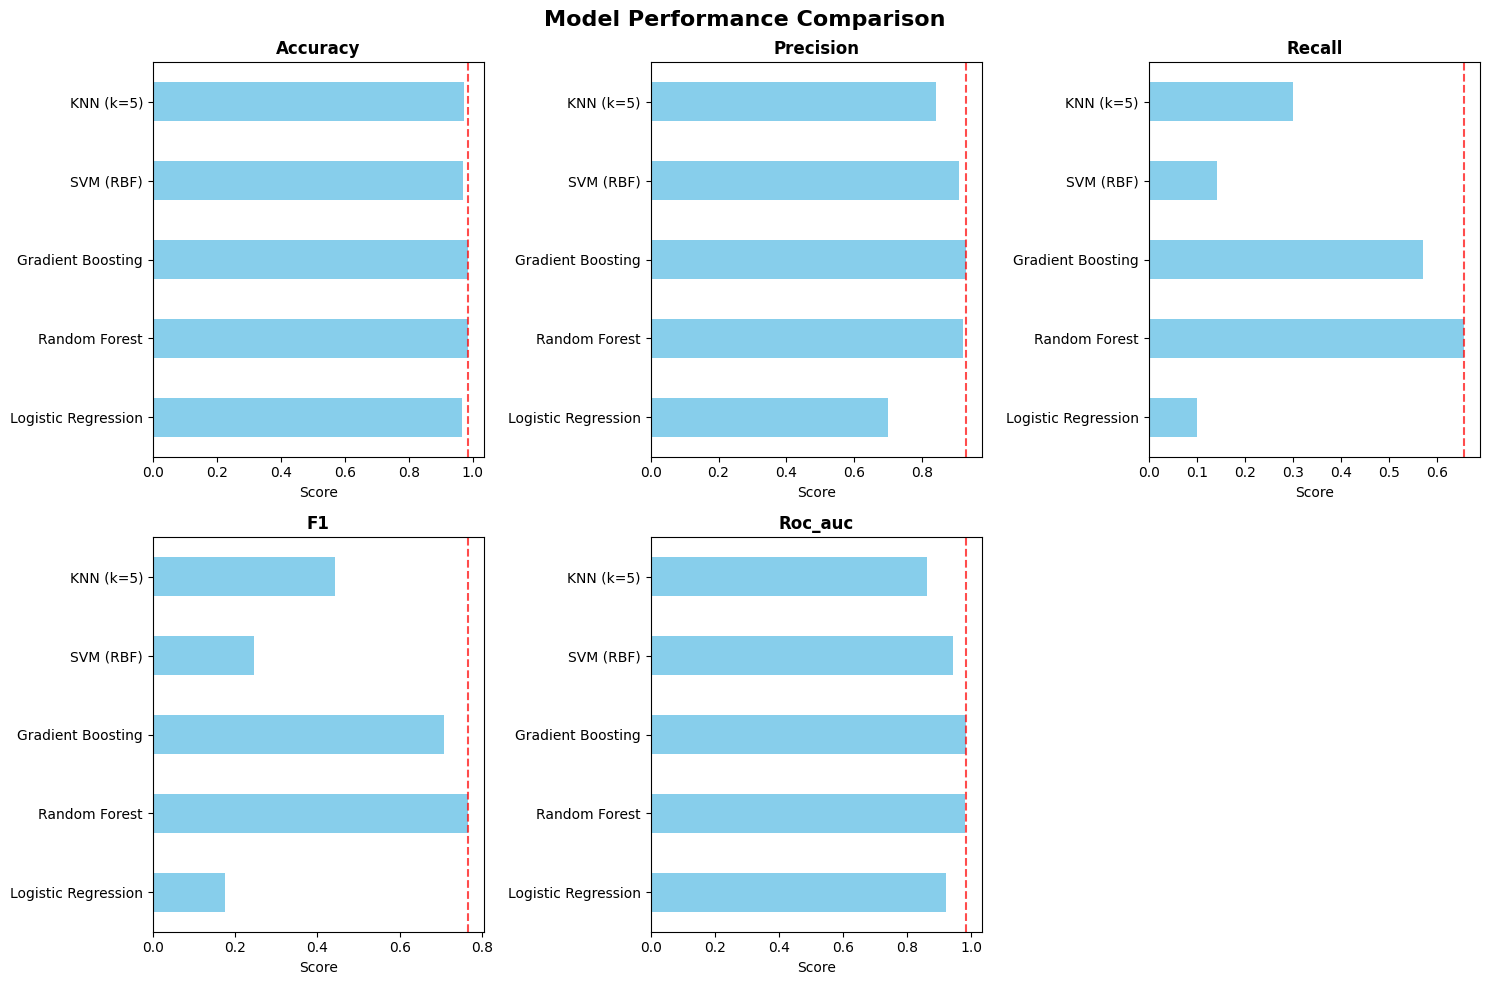


BEST MODELS BY METRIC:
--------------------------------------------------------------------------------
ACCURACY     → Random Forest                  (0.9860)
PRECISION    → Gradient Boosting              (0.9302)
RECALL       → Random Forest                  (0.6571)
F1           → Random Forest                  (0.7667)
ROC_AUC      → Gradient Boosting              (0.9849)


In [16]:
# Visualization: Model Comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for idx, metric in enumerate(metrics):
    ax = axes.flatten()[idx]
    results_df[metric].plot(kind='barh', ax=ax, color='skyblue')
    ax.set_title(metric.capitalize(), fontweight='bold')
    ax.set_xlabel('Score')
    ax.axvline(x=results_df[metric].max(), color='red', linestyle='--', alpha=0.7)

axes.flatten()[-1].remove()
plt.tight_layout()
plt.show()

# Summary Statistics
print("\nBEST MODELS BY METRIC:")
print("-" * 80)
for metric in metrics:
    best_model = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    print(f"{metric.upper():12} → {best_model:30} ({best_score:.4f})")

C:\Users\kabir\AppData\Local\Temp\ipykernel_60072\3567167411.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_best, x='Importance', y='Feature', palette='viridis')


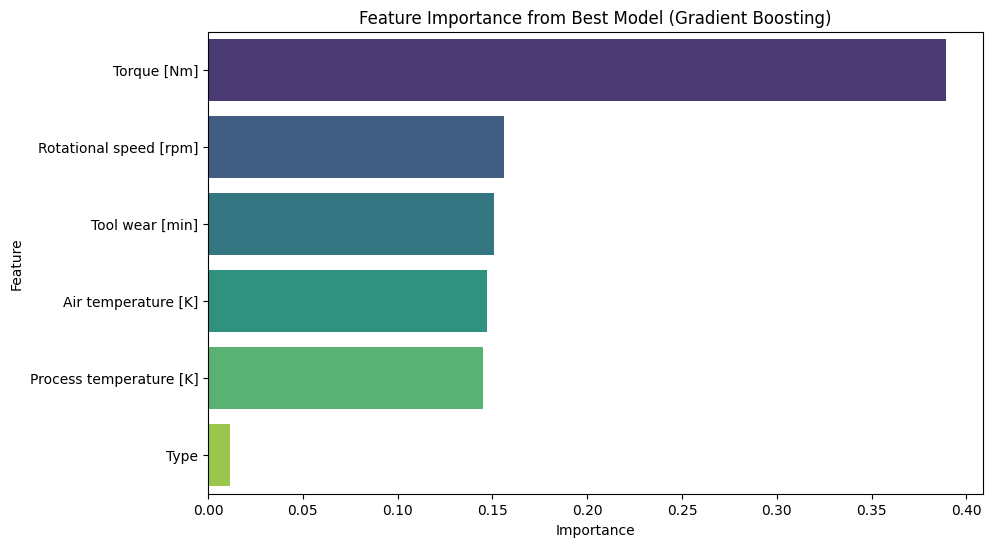

                   Feature  Importance
4              Torque [Nm]    0.389353
3   Rotational speed [rpm]    0.156319
5          Tool wear [min]    0.151069
1      Air temperature [K]    0.146986
2  Process temperature [K]    0.144850
0                     Type    0.011424


In [17]:
# Feature importance from the best model (Gradient Boosting)
best_model_obj = gb
feature_importance_best = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model_obj.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_best, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance from Best Model (Gradient Boosting)')
plt.show()

print(feature_importance_best)